In [2]:
!mamba install pandas scikit-learn seaborn matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn, seaborn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.56 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                        1.5.3     

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Superstore sales dataset.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [4]:
print(df.describe())

            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [6]:
print(df.isnull().mean()*100)

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


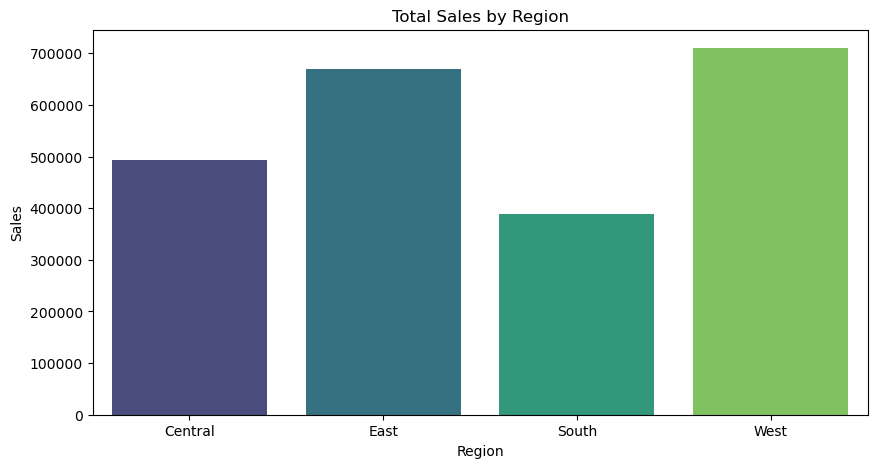

In [7]:
# 1: Total Sales by Region
# Significance: Helps identify which regions are driving supply chain demand.
plt.figure(figsize=(10, 5))
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
sns.barplot(data=region_sales, x='Region', y='Sales', palette='viridis', hue='Region', legend=False)
plt.title('Total Sales by Region')
plt.show()

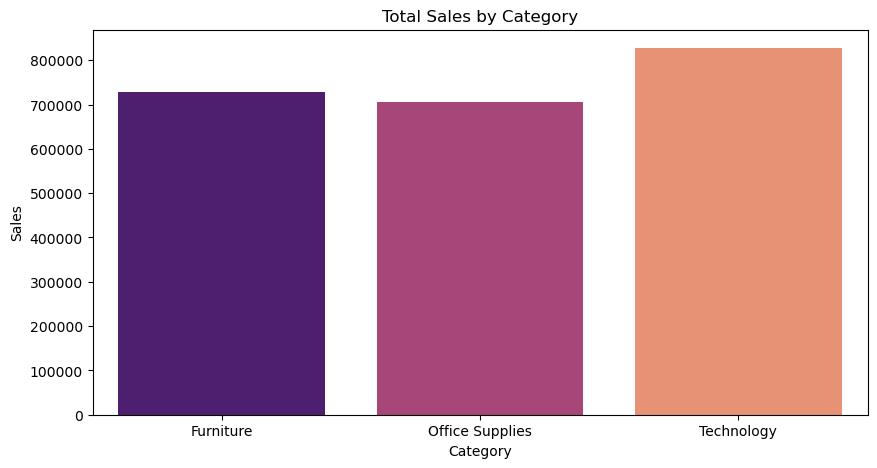

In [8]:
# 2: Sales by Category
# Significance: Shows which product lines require more inventory focus.
plt.figure(figsize=(10, 5))
cat_sales = df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(data=cat_sales, x='Category', y='Sales', palette='magma', hue='Category', legend=False)
plt.title('Total Sales by Category')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
import pandas as pd

#  PREPROCESSING & CLEANING 
#  Selection of predictive columns (dropping noise and targets)
cols_to_drop = ['Order ID', 'Customer Name', 'Product Name', 'City', 'Profit']
df_model = df.drop(columns=cols_to_drop, errors='ignore')

#  Date Feature Engineering (Fixed for DD/MM/YYYY)
df_model['Order Date'] = pd.to_datetime(df_model['Order Date'], dayfirst=True, errors='coerce')

#  Drop any rows where dates failed or data is missing
# This removes the "Input X contains NaN" error.
df_model = df_model.dropna()

# Extract Month/Year
df_model['Month'] = df_model['Order Date'].dt.month
df_model['Year'] = df_model['Order Date'].dt.year
df_model = df_model.drop(columns=['Order Date'], errors='ignore')

# 4. Encoding (Convert text categories to numbers)
df_final = pd.get_dummies(df_model, drop_first=True)

# 5. Data Splitting
X = df_final.drop('Sales', axis=1)
y = df_final['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [11]:
print(f"LINEAR REGRESSION:")
print(f"MAE: ${mean_absolute_error(y_test, lr_pred):.2f}")
print(f"Accuracy (R2): {r2_score(y_test, lr_pred):.2f}")

LINEAR REGRESSION:
MAE: $260.17
Accuracy (R2): 0.51


Text(0, 0.5, 'Predicted Sales ($)')

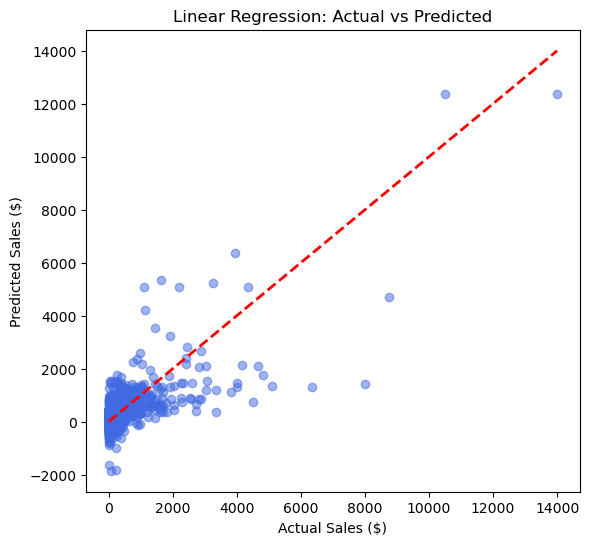

In [20]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')

In [21]:
from sklearn.tree import DecisionTreeRegressor

In [22]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [23]:
print(f"\nDECISION TREE:")
print(f"   - Average Prediction Error (MAE): ${mean_absolute_error(y_test, dt_pred):.2f}")
print(f"   - Accuracy Score (R2): {r2_score(y_test, dt_pred):.4f}")


DECISION TREE:
   - Average Prediction Error (MAE): $229.64
   - Accuracy Score (R2): 0.3479


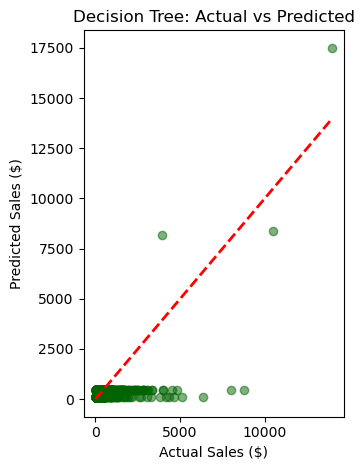

In [24]:
plt.subplot(1, 2, 2)
plt.scatter(y_test, dt_pred, alpha=0.5, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')

plt.tight_layout()
plt.show()

==== FINAL MODEL: RANDOM FOREST ====
Random Forest MAE: $199.35
Random Forest Accuracy (R2): 0.4993


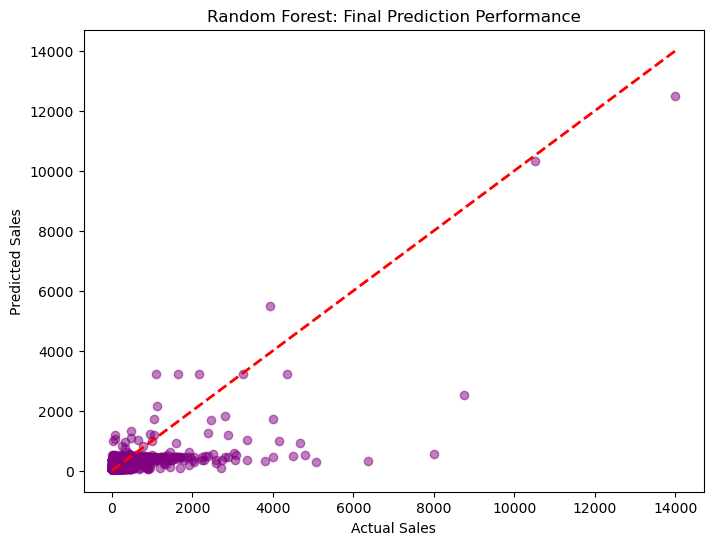

In [25]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest
# We use 100 trees to get a stable, highly accurate prediction.
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict and Evaluate
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"==== FINAL MODEL: RANDOM FOREST ====")
print(f"Random Forest MAE: ${rf_mae:.2f}")
print(f"Random Forest Accuracy (R2): {rf_r2:.4f}")

# 3. Final Comparison Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Final Prediction Performance')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

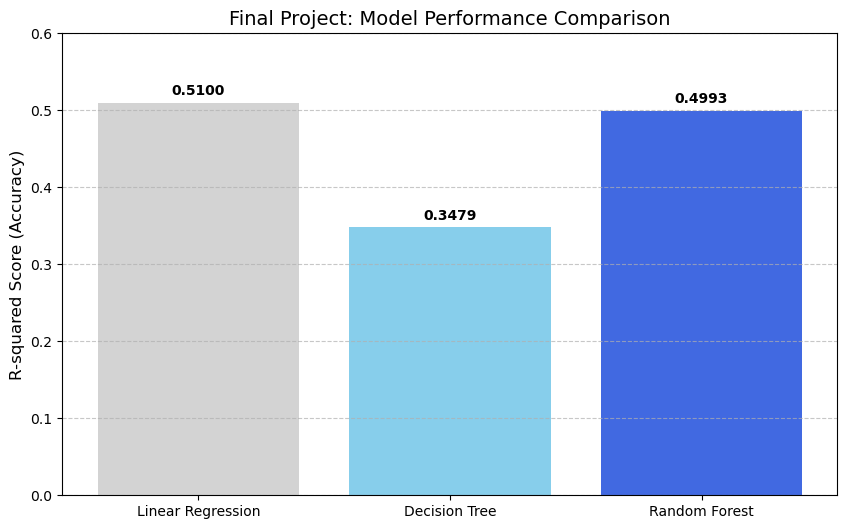

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a comparison dataframe
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy (R2)': [0.51, 0.3479, 0.4993] 
}
comparison_df = pd.DataFrame(results)

# 2. Plotting the Leaderboard
plt.figure(figsize=(10, 6))
colors = ['lightgrey', 'skyblue', 'royalblue']
plt.bar(comparison_df['Model'], comparison_df['Accuracy (R2)'], color=colors)

# Add text labels on top of bars
for i, val in enumerate(comparison_df['Accuracy (R2)']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

plt.ylim(0, 0.6) 
plt.title('Final Project: Model Performance Comparison', fontsize=14)
plt.ylabel('R-squared Score (Accuracy)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()